<a href="https://colab.research.google.com/github/Vibhanshu17/Language-Model-from-Scratch/blob/main/GAI_Tutorial_on_Customizing_GAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Interactive Tutorial: Fine-tuning and Experimentation for Custom Research Solutions***

### **[Shane Storks](www.shanestorks.com)**

#### **PhD Candidate & Graduate Student Research Assistant, Computer Science and Engineering**

*MIDAS Generative AI (GAI) Tutorial Series - November 29, 2023*

---

# [https://tinyurl.com/112923-midas](https://tinyurl.com/112923-midas)

This tutorial will cover some common approaches to customize pre-trained GAI language models (LMs) for empirical research and experimentation, using widely available tools:

1. **Fine-tuning LMs:**   

  a. Traditional fine-tuning ([Radford et al., 2018](https://s3-us-west-2.amazonaws.com/openai-assets/research-covers/language-unsupervised/language_understanding_paper.pdf))

  b. Low-rank adaptation (LoRA; [Hu et al., 2021](https://arxiv.org/abs/2106.09685))

2. **Prompting LMs:**

  a. In-context learning ([Brown et al., 2020](https://arxiv.org/abs/2005.14165))

  b. Chain-of-thought (CoT; [Wei et al., 2022](https://arxiv.org/abs/2201.11903))


Prerequisites:

*   **Python**
*   **(Ideally) basic knowledge of machine learning with PyTorch**


We'll use the [Hugging Face 🤗 Hub](https://huggingface.co/docs/hub/index) for our experiments, which is a centralized resource providing:
* **Datasets commonly used in computational experiments**
* **Open-source AI models**
* **Python libraries, e.g., [`datasets`](https://huggingface.co/docs/datasets/index), [`transformers`](https://huggingface.co/docs/transformers), and [`peft`](https://huggingface.co/docs/peft), which provide helper functions to make it super easy to access and apply the above**

***Content warning:*** *This tutorial involves interacting with AI language models, which can generate harmful and offensive content.*

# Setting up Environment

We are using Google Colab.

**Advantage:** Colab is free and comes with several pre-installed Python libraries (easy setup).

**Disadvantage**: Limited available computing resources; usually not suitable for extended experimentation.


In [ ]:
!rm -r results
!pip install datasets
!pip install -U accelerate
!pip install -U transformers
!pip install -q peft
!pip install optuna

# Fine-tuning LMs

**Fine-tuning** enables us to customize an LM for a specific task for which we already have a substantial amount of available training data. We'll fine-tune GPT-2 ([Radford et al., 2019](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)) because it's smaller (~125M learned parameters) and thus more feasible with our limited compute.

**Advantage:** Smaller LMs can be fine-tuned using less GPU hardware, enabling an affordable and high-performing solution we can host locally.

**Disadvantage:** Fine-tuning requires a large amount of labeled training data, and reduces the LM's generalizability. Also more engineering effort!

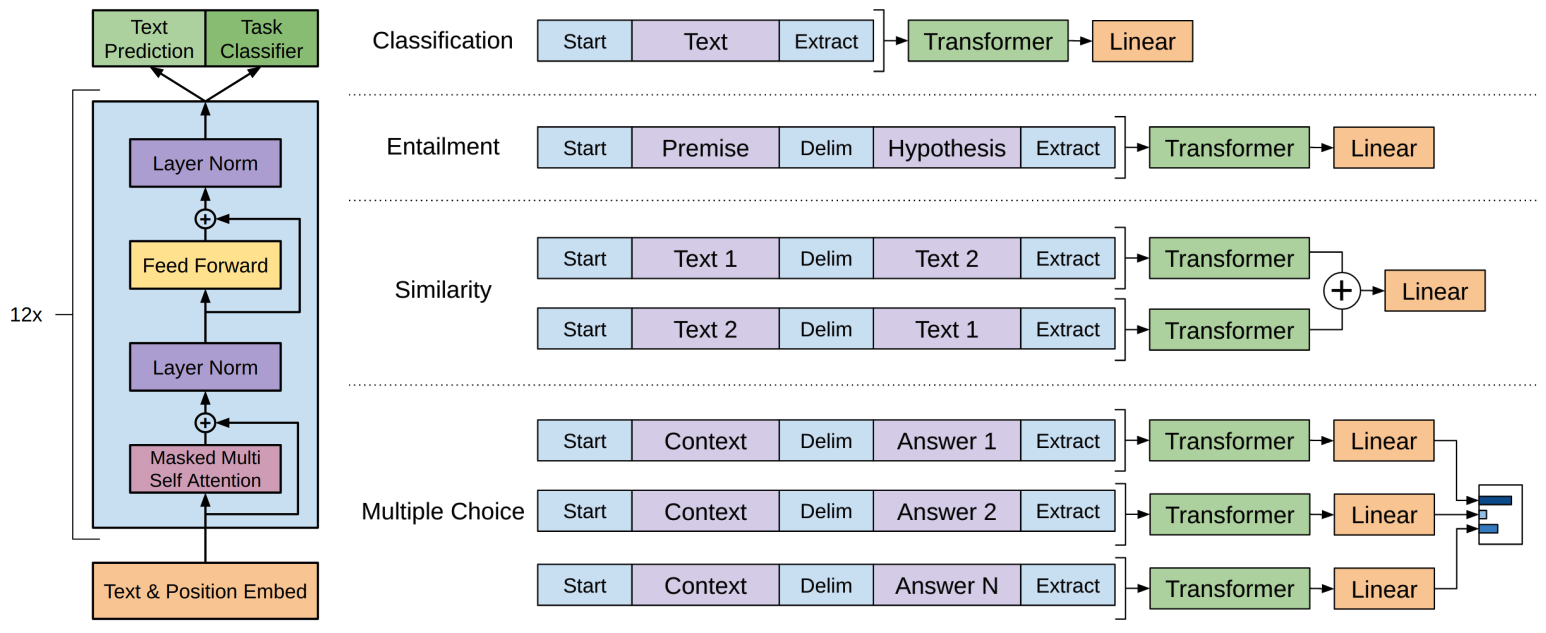

(figure from [Radford et al., 2018](https://s3-us-west-2.amazonaws.com/openai-assets/research-covers/language-unsupervised/language_understanding_paper.pdf))

## Load Dataset for Experiments

First, we need a problem to fine-tune GPT-2 on. We'll use **sentiment analysis**, which is a text classification task requiring the system to judge the sentiment of a text (e.g., negative or positive).

We'll use `datasets` to download the Stanford Sentiment Treebank (SST-2):

In [ ]:
from datasets import load_dataset

dataset = load_dataset("sst2") # Stanford Sentiment Treebank 2.0

# Go to https://huggingface.co/datasets to explore other available datasets!

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd
selected_rows = [dataset['validation'][i] for i in range(2)]
selected_rows = pd.DataFrame(selected_rows)
display(selected_rows)

,idx,sentence,label
0,0,it 's a charming and often affecting journey .,1
1,1,unflinchingly bleak and desperate,0


Text classification is just one type of language task we can apply LMs to. You can fine-tune LMs on many different types of tasks, including:
* **Token classification** (e.g., part-of-speech tagging, named entity recognition)
* **Text-to-text generation** (e.g., machine translation,
summarization)

***Note:*** *You can browse other available datasets at https://huggingface.co/datasets.*


## Load a Pre-Trained LM with Classification Layer


We can use the `AutoModel` helper functions to easily set up:
* A GPT-2 tokenizer, i.e., the module that converts raw text into tokens from GPT-2's training vocabulary
* A [`GPT2ForSequenceClassification`](https://github.com/huggingface/transformers/blob/514de24abfd4416aeba6a6455ad5920f57f3567d/src/transformers/models/gpt2/modeling_gpt2.py#L1383), i.e., a PyTorch module consisting of GPT-2 followed by a linear classification layer



In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import gc

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

# Load model
MODEL_NAME = "gpt2" # Model name in Hugging Face Hub
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                           num_labels=2) # number of class labels
model.config.pad_token_id = model.config.eos_token_id

# Move model to GPU if available
if torch.cuda.is_available():
  model.cuda()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


As expected, the classification layer `score` is not initialized and should be trained, as mentioned in the above warning.

We can confirm the model architecture by printing. The [source code](https://github.com/huggingface/transformers/blob/v4.35.2/src/transformers/models/gpt2/modeling_gpt2.py#L1383) shows more details on how the `score` interfaces with the LM.

In [ ]:
from pprint import pprint
import numpy as np

pprint(model)

# Credit: https://discuss.pytorch.org/t/how-do-i-check-the-number-of-parameters-of-a-model/4325/8
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(f"\ntrainable params: {params}")

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=2, bias=False)
)

trainable params: 124441344


***Note:*** *You can also [load other models in this way](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) for different types of downstream tasks:*
* *Language modeling and generation*
* *Question answering*
* *Token classification*

*If you have more compute and want to use newer or larger models, you can make minor modifications to the code above. You can browse all available models [here](https://huggingface.co/models).*

## Basics of Interacting with LMs

We can test out the tokenizer with a simple prompt to see how it works:

In [ ]:
prompt = "This is the most uninteresting movie I've ever seen."
tokens = tokenizer(prompt,
                   return_tensors="pt")
print("tokens:", tokens)

tokens: {'input_ids': tensor([[ 1212,   318,   262,   749,   555, 47914,  3807,   314,  1053,  1683,
          1775,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
tokens_decoded = [tokenizer.decode(token) for token in tokens['input_ids'][0]]
print("decoded tokens:", tokens_decoded)

decoded tokens: ['This', ' is', ' the', ' most', ' un', 'interesting', ' movie', ' I', "'ve", ' ever', ' seen', '.']


After tokenizing a sentence, we can pass it into the model.

In [ ]:
tokens = tokens.to(model.device)
classification_scores = model(**tokens).logits
print("scores:", classification_scores)

scores: tensor([[3.0381, 6.0416]], device='cuda:0', grad_fn=<IndexBackward0>)


In [ ]:
from torch.nn.functional import softmax

classification_scores = softmax(classification_scores,
                                dim=-1)
print("normalized scores:", classification_scores)

normalized scores: tensor([[0.0473, 0.9527]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


Since the model isn't fine-tuned yet, it just predicts random scores for each class label.

***Note:*** *LM wrappers like `GPT2ForSequenceClassification` automatically include an appropriate loss function (e.g., cross-entropy loss for classification), making it easy to calculate loss during training. See below.*

In [ ]:
from torch.nn.functional import softmax

labels = torch.tensor([0]).to(model.device)
loss = model(**tokens, labels=labels).loss
print("loss:", loss)

loss: tensor(3.0519, device='cuda:0', grad_fn=<NllLossBackward0>)


## Preprocess the Dataset

Normally, we should use all available training data for fine-tuning the LM.

But for quick training during this demonstration, we'll downsample the training data:

In [ ]:
import random
import torch

SAMPLE_SIZE = 1000
train_sample = random.sample(range(len(dataset['train'])), SAMPLE_SIZE)
dataset['train'] = dataset['train'].filter(lambda example: example['idx'] in train_sample)

Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

In SST-2 and many other benchmark datasets, the labels for the testing data are not publicly released.

For demonstration purposes, we'll split the labeled validation data into two partitions (one for validation, one for testing):

In [ ]:
dataset['test'] = dataset['validation'].filter(lambda example: example['idx'] >= 400)
dataset['validation'] = dataset['validation'].filter(lambda example: example['idx'] < 400)

print(f"{len(dataset['validation'])} validation examples")
print(f"{len(dataset['test'])} test examples")

Filter:   0%|          | 0/872 [00:00<?, ? examples/s]

Filter:   0%|          | 0/872 [00:00<?, ? examples/s]

400 validation examples
472 test examples


***Note:*** *Training data is used for fine-tuning the LM's learnable parameters. Validation data is used to evaluate the model's performance during training, and determine the best **checkpoint** of the model achieved. We then use testing data for a separate, held-out evaluation.*

Before we can fine-tune the model, we must tokenize the whole dataset and gather the labels:

In [ ]:
import torch
from torch.utils.data import TensorDataset, Dataset

# Set a padding token on the tokenizer
tokenizer.pad_token = tokenizer.eos_token

# Tokenize all the data
encodings_train = tokenizer(dataset['train']['sentence'],
                            return_tensors="pt",
                            padding=True,) # Pad to a consistent tokenized sequence length
labels_train = torch.tensor(dataset['train']['label'])


encodings_validation = tokenizer(dataset['validation']['sentence'],
                                 return_tensors="pt",
                                 padding=True,) # Pad to a consistent tokenized sequence length
labels_validation = torch.tensor(dataset['validation']['label'])


encodings_test = tokenizer(dataset['test']['sentence'],
                           return_tensors="pt",
                           padding=True,) # Pad to a consistent tokenized sequence length
labels_test = torch.tensor(dataset['test']['label'])


print("train tokens:", encodings_train['input_ids'].shape)
print("train labels:", labels_train.shape)

print("validation tokens:", encodings_validation['input_ids'].shape)
print("validation labels:", labels_validation.shape)

print("test tokens:", encodings_test['input_ids'].shape)
print("test labels:", labels_test.shape)

train tokens: torch.Size([1000, 52])
train labels: torch.Size([1000])
validation tokens: torch.Size([400, 55])
validation labels: torch.Size([400])
test tokens: torch.Size([472, 61])
test labels: torch.Size([472])


Create a specialized Dataset class to return important information for interfacing with LM as we did above:


In [ ]:
from torch.utils.data import Dataset
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextClassificationDataset(encodings_train, labels_train)
validation_dataset = TextClassificationDataset(encodings_validation, labels_validation)
test_dataset = TextClassificationDataset(encodings_test, labels_test)

## Traditional Fine-Tuning

For simplicity, we'll use the [`Trainer`](https://huggingface.co/docs/transformers/main_classes/trainer) wrapper from Hugging Face to fine-tune GPT-2.

***Note:*** *For those already comfortable with PyTorch, you can also apply a [traditional PyTorch training loop](https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#) to fine-tune the model, as shown [here](https://huggingface.co/transformers/v3.4.0/custom_datasets.html#fine-tuning-with-native-pytorch-tensorflow). This would give you more flexibility to adjust the training procedure.*

First, we'll define the training arguments, including several **hyper-parameters**.

**Hyper-parameters** are numerical properties of the training procedure that we must define, and they may affect the final results. For now, let's choose some common values for them.

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',          # output directory

    learning_rate=2e-5,              # learning rate
    num_train_epochs=10,             # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=128,  # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay

    load_best_model_at_end=True,     # load best model after training so we can evaluate it
    logging_strategy="epoch",        # log training loss after each epoch
    evaluation_strategy="epoch",     # evaluate the model on validation set after each epoch
    save_strategy="epoch",           # save a model checkpoint after each epoch
)

***Note:*** *There are many more arguments you can manipulate in `TrainingArguments` for your specific application, including the optimizer used. Check the docs for more information!*

`Trainer` does not return common classification metrics (e.g., accuracy) by default. We can define a custom metrics function:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids # Ground truth labels
    preds = pred.predictions.argmax(-1) # LM predictions

    # Calculate accuracy
    accuracy = accuracy_score(labels, preds)

   # Calculate precision, recall, and F1-score
    precision = precision_score(labels, preds, average='weighted')
    recall = recall_score(labels, preds, average='weighted')
    f1 = f1_score(labels, preds, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

Now, we're ready to fine-tune the LM. It only takes a couple lines of code.

In [ ]:
trainer = Trainer(
    model=model,                     # the instantiated 🤗 Transformers model to be trained
    args=training_args,              # training arguments, defined above
    train_dataset=train_dataset,     # training dataset
    eval_dataset=validation_dataset, # evaluation dataset
    compute_metrics=compute_metrics, # classification metrics
)
trainer.train()

<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.886300,0.726056,0.505000,0.520658,0.505000,0.473912
2,0.781100,0.708358,0.540000,0.635455,0.540000,0.463897
3,0.739200,0.664203,0.600000,0.737629,0.600000,0.543398
4,0.629100,0.439636,0.817500,0.829979,0.817500,0.816611
5,0.424500,0.313601,0.885000,0.887210,0.885000,0.885020
6,0.292300,0.327422,0.887500,0.887819,0.887500,0.887386
7,0.213900,0.369567,0.860000,0.861633,0.860000,0.860042
8,0.192800,0.429566,0.865000,0.874133,0.865000,0.864645
9,0.111400,0.530345,0.865000,0.865800,0.865000,0.865054
10,0.068200,0.680743,0.867500,0.867662,0.867500,0.867532


<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to

TrainOutput(global_step=630, training_loss=0.43387051839677115, metrics={'train_runtime': 221.3056, 'train_samples_per_second': 45.186, 'train_steps_per_second': 2.847, 'total_flos': 265379512320000.0, 'train_loss': 0.43387051839677115, 'epoch': 10.0})

During training, **losses** will be periodically calculated on the training and validation data:

* These are continuous quantitative measures for how close the LM's outputs are to the ground truth labels for our sentiment analysis task

* In general, your training loss should continuously decrease throughout training, and your validation loss should mostly decrease through training, and eventually stop decreasing or start increasing.

* This indicates **convergence** of the model: the model has learned as much transferable knowledge as it can from the training data, and can apply what it learned to the held-out validation data.

* If your model is not converging, you can use some rules of thumb to diagnose the problem:

  1. If your training loss is not decreasing or very slowly decreasing, you should increase the learning rate.
  2. If your training loss is increasing or jumping around, you should lower the learning rate.
  3. If your training loss is decreasing but your validation loss is increasing or jumping around, your model is **overfitting**. You should lower the learning rate, or apply regularization techniques like dropout (which our LM architecture already applies).

We can observe through our losses that the model has converged:

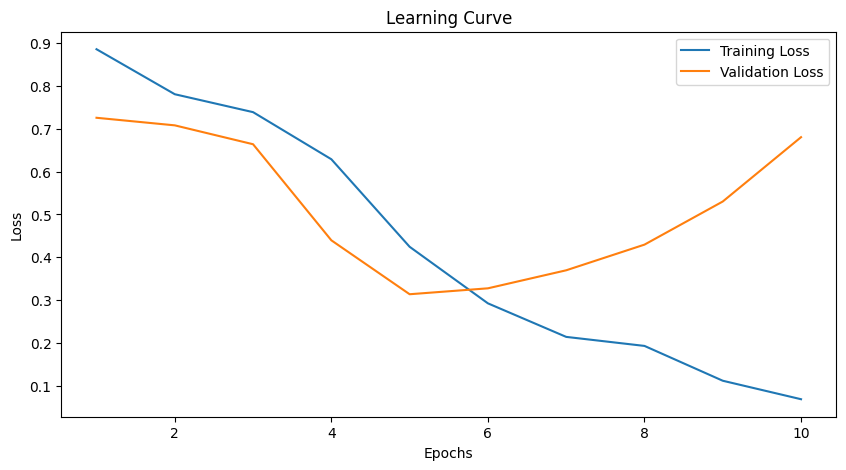

In [ ]:
import json
import matplotlib.pyplot as plt
from transformers.modelcard import parse_log_history

def plot_learning_curve(logs):
    # Collect losses throughout training
    training_loss = [log['loss'] for log in logs if 'loss' in log]
    training_loss_epochs = [log['epoch'] for log in logs if 'loss' in log]

    validation_loss = [log['eval_loss'] for log in logs if 'eval_loss' in log]
    validation_loss_epochs = [log['epoch'] for log in logs if 'eval_loss' in log]

    plt.figure(figsize=(10, 5))
    plt.plot(training_loss_epochs, training_loss, label='Training Loss')
    plt.plot(validation_loss_epochs, validation_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.show()

logs = trainer.state.log_history
plot_learning_curve(logs)

Evaluate the best model (out of all training epochs) on the validation data:

In [ ]:
trainer.evaluate(eval_dataset=test_dataset)

<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


{'eval_loss': 0.32443302869796753,
 'eval_accuracy': 0.8580508474576272,
 'eval_precision': 0.8591405982675095,
 'eval_recall': 0.8580508474576272,
 'eval_f1': 0.8579430855962088,
 'eval_runtime': 1.8591,
 'eval_samples_per_second': 253.884,
 'eval_steps_per_second': 2.152,
 'epoch': 10.0}

## Hyperparameter Search (Example)

We manually selected most of our training hyperparameters. For best results, we should do a search over several possible values.

Specifically, we'll use a **grid search** over learning rate, powered by the `optuna` library:

In [ ]:
# Can select many values to search over; only select a few for demonstration purposes
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_categorical("learning_rate", [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32, 64, 128]),
    }

# For hyperparameter search, also need to provide a function to initialize the model
def model_init():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                              num_labels=2) # number of class labels
    model.config.pad_token_id = model.config.eos_token_id
    return model

***Note:*** *You could also search over multiple values of batch size, but to optimize for time, we'll continue to use the maximum batch size that can fit on the GPU in Colab.*

We'll repeat some of the same setup steps as before:

In [ ]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import gc

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

training_args = TrainingArguments(
    output_dir='./results',          # output directory

    num_train_epochs=10,             # total number of training epochs
    per_device_train_batch_size=128, # batch size per device during training
    per_device_eval_batch_size=256,  # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay

    load_best_model_at_end=True,     # load best model after training so we can evaluate it
    logging_strategy="epoch",        # log training loss after each epoch
    evaluation_strategy="epoch",     # evaluate the model on validation set after each epoch
    save_strategy="epoch",           # save a model checkpoint after each epoch
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate accuracy
    accuracy = accuracy_score(labels, preds)

   # Calculate precision, recall, and F1-score
    precision = precision_score(labels, preds, average='weighted')
    recall = recall_score(labels, preds, average='weighted')
    f1 = f1_score(labels, preds, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

trainer = Trainer(
    model_init=model_init,           # the instantiated 🤗 Transformers model to be trained
    args=training_args,              # training arguments, defined above
    train_dataset=train_dataset,     # training dataset
    eval_dataset=validation_dataset, # evaluation dataset
    compute_metrics=compute_metrics, # classification metrics
)

Then we can fine-tune the LM with hyperparameter search:

In [ ]:
trainer.hyperparameter_search(
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=25 # Usually want this to be the number of combinations of hyperparameters searched over
)

Again, evaluate the best model (out of all the hyper-parameter combinations) on the test data:

In [ ]:
trainer.evaluate(eval_dataset=test_dataset)

## Low-Rank Adaptation (LoRA)

We can use similar code for parameter-efficient fine-tuning methods (PEFT) like Low-Rank Adaptation (LoRA; [Hu et al., 2021](https://arxiv.org/pdf/2106.09685.pdf)) to fine-tune GPT-2.

**Advantage:** Enables faster and lower-memory (!) fine-tuning by freezing the pre-trained LM parameters, and learning weight updates directly as a decomposition of the weight update matrix.

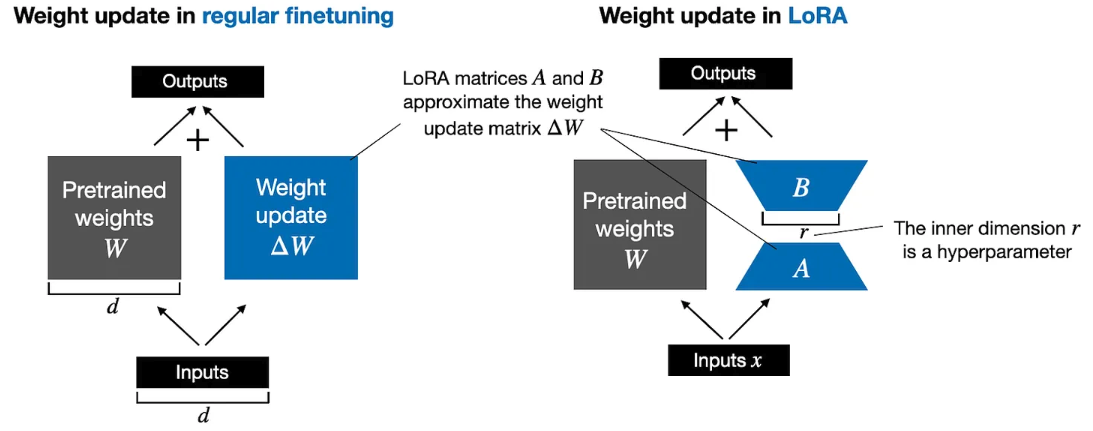

(figure from [Sebastian Raschka](https://magazine.sebastianraschka.com/p/practical-tips-for-finetuning-llms))

First, initialize a `PeftModel` from GPT-2. There are much fewer trainable parameters!

***Note:*** *As outlined in the LoRA paper, $r$ and $\alpha$ are hyperparameters you could search over for best results.*

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)
from peft import get_peft_config, PeftModel, PeftConfig, get_peft_model, LoraConfig, TaskType

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import gc

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

# Load model
MODEL_NAME = "gpt2" # Model name in Hugging Face Hub
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                           num_labels=2) # number of class labels
model.config.pad_token_id = model.config.eos_token_id

# Move model to GPU if available
if torch.cuda.is_available():
  model.cuda()

peft_config = LoraConfig(task_type=TaskType.SEQ_CLS,  # configured for text classification
                         inference_mode=False,        # enable training - for inference, we can pre-compute the weight update matrix
                         r=8,                         # dimension of low-rank matrices
                         lora_alpha=16,               # scaling coefficient of weight update
                         lora_dropout=0.1,            # dropout regularization on LoRA weights
                         bias="all")                  # use LoRA to train "all" biases (alternatives: "none", "lora_only")
model = get_peft_model(model, peft_config)

print("\n")
model.print_trainable_parameters()

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




trainable params: 398,592 || all params: 124,737,792 || trainable%: 0.3195438957264852


/usr/local/lib/python3.10/dist-packages/peft/tuners/lora/model.py:311: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Now, use the same code as before to fine-tune and evaluate the model:

In [ ]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import gc

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

training_args = TrainingArguments(
    output_dir='./results',          # output directory

    learning_rate=3e-4,              # learning rate
    num_train_epochs=10,             # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=128,  # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay

    load_best_model_at_end=True,     # load best model after training so we can evaluate it
    logging_strategy="epoch",        # log training loss after each epoch
    evaluation_strategy="epoch",     # evaluate the model on validation set after each epoch
    save_strategy="epoch",           # save a model checkpoint after each epoch
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate accuracy
    accuracy = accuracy_score(labels, preds)

   # Calculate precision, recall, and F1-score
    precision = precision_score(labels, preds, average='weighted')
    recall = recall_score(labels, preds, average='weighted')
    f1 = f1_score(labels, preds, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

Fine-tune the model:

In [ ]:
trainer = Trainer(
    model=model,                     # the instantiated 🤗 Transformers model to be trained
    args=training_args,              # training arguments, defined above
    train_dataset=train_dataset,     # training dataset
    eval_dataset=validation_dataset, # evaluation dataset
    compute_metrics=compute_metrics, # classification metrics
)
trainer.train()

<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.406200,1.648784,0.480000,0.230400,0.480000,0.311351
2,0.948800,0.747788,0.482500,0.493643,0.482500,0.412733
3,0.690100,0.664678,0.592500,0.677415,0.592500,0.549160
4,0.544700,0.444640,0.812500,0.830628,0.812500,0.810963
5,0.409300,0.473503,0.807500,0.832395,0.807500,0.805120
6,0.384000,0.335666,0.857500,0.859382,0.857500,0.857535
7,0.355100,0.632750,0.760000,0.815199,0.760000,0.751655
8,0.357400,0.457069,0.857500,0.857495,0.857500,0.857449
9,0.284400,0.355518,0.862500,0.863899,0.862500,0.862547
10,0.227000,0.370317,0.857500,0.857740,0.857500,0.857356


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourc

TrainOutput(global_step=630, training_loss=0.6606929173545232, metrics={'train_runtime': 106.845, 'train_samples_per_second': 93.594, 'train_steps_per_second': 5.896, 'total_flos': 266304430080000.0, 'train_loss': 0.6606929173545232, 'epoch': 10.0})

Test the model:

In [ ]:
trainer.evaluate(eval_dataset=test_dataset)

<ipython-input-14-1d865fbfe659>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-14-1d865fbfe659>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


{'eval_loss': 0.33930668234825134,
 'eval_accuracy': 0.8601694915254238,
 'eval_precision': 0.8605838366407823,
 'eval_recall': 0.8601694915254238,
 'eval_f1': 0.8601293103448274,
 'eval_runtime': 1.9191,
 'eval_samples_per_second': 245.95,
 'eval_steps_per_second': 2.084,
 'epoch': 10.0}

With traditional fine-tuning, it took almost 5 minutes to fine-tune the LM for 10 epochs.

With LoRA, it takes only 2 minutes - and still reaches about the same level of accuracy! 🥳

# Prompting LMs

As LMs have become larger and larger, it has become possible to apply them directly to tasks through text-based **prompting**, removing the need for fine-tuning. We can host a 6.7B-parameter instance of OPT ([Zhang et al., 2022](https://arxiv.org/abs/2205.01068)) in Colab to experiment with prompting.

**Advantage:** Easier, less expensive, generalizable, and adaptable. No need for a large amount of training data.

**Disadvantage:** The larger (and best) LMs require more GPU hardware and thus may not be possible for everyone to host (e.g., in Colab). Companies like OpenAI provide paid APIs to access the best models, e.g., GPT-4, which has its own disadvantages of cost and lack of data privacy. Therefore, fine-tuning can be a cheaper high-performing alternative for many tasks.

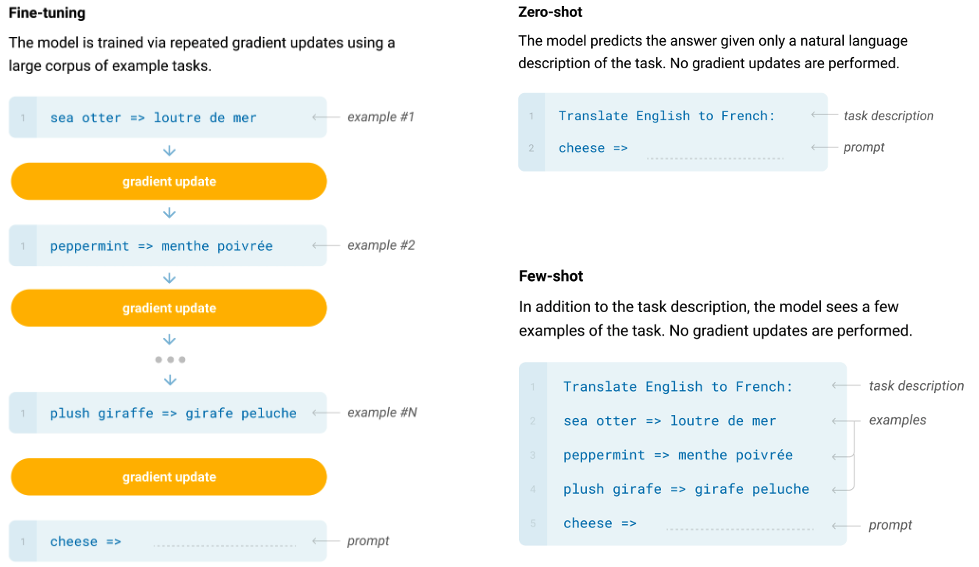

(figures from [Brown et al., 2020](https://arxiv.org/pdf/2005.14165.pdf))

## Prompting with Hugging Face Pipelines

HuggingFace provides various [pipelines](https://huggingface.co/docs/transformers/main_classes/pipelines) to easily prompt pre-trained LMs for common purposes.

We'll see several possible types of tasks you can apply LMs to through prompting, and learn some basic **prompt engineering** tricks.

***Note:*** *We apply a few tricks to make the model fit within the constrained CPU and GPU memory in Colab.*

In [ ]:
from transformers import pipeline
import torch

MODEL_NAME = "facebook/opt-6.7b"
generator = pipeline(model=MODEL_NAME,
                     torch_dtype=torch.float16,
                     device_map="auto")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

Pipelines make it easy to generate text with LMs:

In [ ]:
generator("The University of Michigan is ",
          max_new_tokens=20)

[{'generated_text': 'The University of Michigan is ~~the~~ the only school in the Big Ten that has never had a Heisman winner.\nI'}]

***Note:*** *The code for using paid APIs like the [OpenAI API](https://platform.openai.com/docs/api-reference) looks quite similar to this.*

## Impact of Temperature in Generation

`temperature` is a parameter between 0.0 and 1.0 used by the decoding algorithm to introduce some randomness into generated language. A zero temperature is good for tasks where factuality is important, while a nonzero temperature enables more diverse outputs.

***Note:*** *For research applications, be sure to account for randomness in language generation when interpreting experimental results.*

### Math

In math problems, factuality is important, so zero temperature is best.

In [ ]:
generator("1 + 1 =",
          max_new_tokens=1,
          return_full_text=False,
          temperature=0.0)

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:381: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


[{'generated_text': ' 2'}]

In [ ]:
generator("1 + 1 =",
          max_new_tokens=20,
          return_full_text=False,
          do_sample=True,
          temperature=1.0)

[{'generated_text': " 2, the problem in the formula is 1/0  So if you can't understand how this"}]

### Translation

In translation, factuality is also important, so a nonzero temperature may be suitable.

***Note:*** *For longer translations that are more open to interpretation, using a slightly larger temperature may be okay.*

In [ ]:
generator(
    "English: I love my dog. German:",
    max_new_tokens=8,
    return_full_text=False,
    temperature=0.0,
)

[{'generated_text': ' Ich liebe mein Hund.'}]

In [ ]:
generator(
    "English: I love my dog. German:",
    max_new_tokens=8,
    return_full_text=False,
    do_sample=True,
    temperature=1.0,
)

[{'generated_text': ' Dachs und Dächer.'}]

### Text Generation

For free-form text generation, e.g., to generate dialogue or stories, a zero temperature leads to redundant generation:

In [ ]:
text = generator(
    "A: Hello!"
    "\nB:",
    max_new_tokens=50,
    return_full_text=True,
    temperature=0.0,
)
for t in text[0]['generated_text'].split('\n'):
  print(t)

A: Hello!
B: Hello!
A: I'm a little bit nervous.
B: I'm a little bit nervous.
A: I'm a little bit nervous.
B: I'm a little bit nervous.
A: I'm a little bit


But a temperature too large will sacrifice coherence:

In [ ]:
text = generator(
    "A: Hello!"
    "\nB:",
    max_new_tokens=50,
    return_full_text=True,
    do_sample=True,
    temperature=1.0,
)
for t in text[0]['generated_text'].split('\n'):
  print(t)

A: Hello!
B: Have you seen my husband?

A: No, have you seen my husband?

B: No, do you have my husband?

A: No, how do I get my husband?

B: Ok, you


Using a temperature between 0.0 and 1.0 may be the best choice:

In [ ]:
text = generator(
    "A: Hello!"
    "\nB:",
    max_new_tokens=50,
    return_full_text=True,
    do_sample=True,
    temperature=0.5,
)
for t in text[0]['generated_text'].split('\n'):
  print(t)

A: Hello!
B: I'm new to this forum.
A: Hi!
B: I have a question about the "C" key.
A: What is the "C" key?
B: It's the key that says "C" on


## In-Context Learning

Our experiments so far have been **zero-shot**, i.e., with no examples of the task given before inference.

To improve performance in prompting settings, we can take advantage of LLMs' **in-context learning** capabilities and provide some demonstrations in the prompt ([Brown et al., 2020](https://arxiv.org/abs/2005.14165)).

In [ ]:
generator(
    "Question: How many legs does a ladybug have? Answer:",
    max_new_tokens=10,
    return_full_text=False,
    temperature=0.0,
)

[{'generated_text': " Four.\nI'm not sure if you're"}]

In [ ]:
generator(
    "Question: How many legs does a bird have? Answer: 2\n"
    "Question: How many legs does an octopus have? Answer: 8\n"
    "Question: How many legs does a dog have? Answer: 4\n"
    "Question: How many legs does a ladybug have? Answer:",
    max_new_tokens=1,
    return_full_text=False,
    temperature=0.0,
)

[{'generated_text': ' 6'}]

## Chain-of-Thought Prompting

**Chain-of-thought** (CoT) prompting ([Wei et al., 2022](https://arxiv.org/abs/2201.11903)) is an in-context learning trick where we provide explanations in our demonstrations of the task. This can be especially helpful for tasks requiring multiple steps of reasoning, like math problems.




In [ ]:
generator(
    "Question: What is 20 - ( 8 * 2 )? Answer:",
    max_new_tokens=1,
    return_full_text=False,
    temperature=0.0,
)

[{'generated_text': ' 20'}]

In [ ]:
generator(
    "Question: What is 32 + ( 4 / 2 )? Answer: 34\n"
    "Question: What is 3 - ( 0 * 9 )? Answer: 3\n"
    "Question: What is 17 + ( 3 * 3 )? Answer: 26\n"
    "Question: What is 20 - ( 8 * 2 )? Answer:",
    max_new_tokens=1,
    return_full_text=False,
    temperature=0.0,
)

[{'generated_text': ' 24'}]

In [ ]:
generator(
    "Question: What is 32 + ( 4 / 2 )? Answer: 4 / 2 is 2, and 32 + 2 is 34.\n"
    "Question: What is 3 - ( 0 * 9 )? Answer: 0 * 9 is 0, and 3 - 0 is 3.\n"
    "Question: What is 17 + ( 3 * 3 )? Answer: 3 * 3 is 9, and 17 + 9 is 26.\n"
    "Question: What is 20 - ( 8 * 2 )? Answer: ",
    max_new_tokens=13,
    return_full_text=False,
    temperature=0.0,
)

[{'generated_text': ' 8 * 2 is 16, and 20 - 16 is 4.'}]

This is just a simple example. With larger LMs, you can tackle more complicated reasoning problems with CoT!

## Prompting LMs for Benchmark Evaluation

Let's return to our original sentiment analysis problem:

In [ ]:
from datasets import load_dataset
import pandas as pd
import random
import torch

# Load the dataset
dataset = load_dataset("sst2") # Stanford Sentiment Treebank 2.0
selected_rows = [dataset['validation'][i] for i in range(2)]
selected_rows = pd.DataFrame(selected_rows)
display(selected_rows)

# Take 200 validation data as the testing dataset
dataset['test'] = dataset['validation'].filter(lambda example: example['idx'] < 200)
print(f"{len(dataset['test'])} test examples")

,idx,sentence,label
0,0,it 's a charming and often affecting journey .,1
1,1,unflinchingly bleak and desperate,0


Filter:   0%|          | 0/872 [00:00<?, ? examples/s]

200 test examples


It's straightforward to evaluate the LLM on SST-2. We'll use the `PipelineDataset` helper class to build the prompt template, and evaluate the accuracy at varying numbers of in-context demonstrations (i.e., *shots*).

In [ ]:
from tqdm.auto import tqdm
from transformers.pipelines.pt_utils import PipelineDataset
from sklearn.metrics import accuracy_score

def process_fewshot(item, demonstrations):
  prompt = ""
  for demo in demonstrations:
    label = "negative" if item['label'] == 0 else "positive" # Convert labels to tokens
    prompt += f"Sentence: {item['sentence']} Sentiment: {label}\n"
  prompt += f"Sentence: {item['sentence']} Sentiment: "
  return prompt

shot_results = {}
for n_shots in [2, 4, 8, 16]:
  # Sample n training examples for few-shot demonstrations
  params_fewshot = {
      "demonstrations": dataset['train'].filter(lambda example: 0 <= example['idx'] < n_shots)
  }

  preds = []
  for out in tqdm(generator(PipelineDataset(dataset["test"],
                                            process_fewshot,
                                            params_fewshot),
                            max_new_tokens=1,
                            return_full_text=False,
                            temperature=0.0)):
      generated_text = out[0]['generated_text']
      if generated_text.strip().lower() == "negative":
        pred = 0
      elif generated_text.strip().lower() == "positive":
        pred = 1
      else:
        # LM may output some other word - choose negative by default
        pred = 0
      preds.append(pred)

  labels = [item['label'] for item in dataset['test']]
  accuracy = accuracy_score(labels, preds)
  shot_results[n_shots] = accuracy

Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:381: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:381: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:381: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


***Note:*** *There are many different choices to make when using LMs for a systematic evaluation like this, some of which were covered earlier.*

*For example, instead of having the LM generate a token, we could instead dig into its probabilities for all possible next words in the vocabulary to compare* $p(\text{"negative"})$ *and* $p(\text{"positive"})$. This would avoid handling the situation where the LM outputs an unexpected word.

### Interpreting Results

Plot the results:

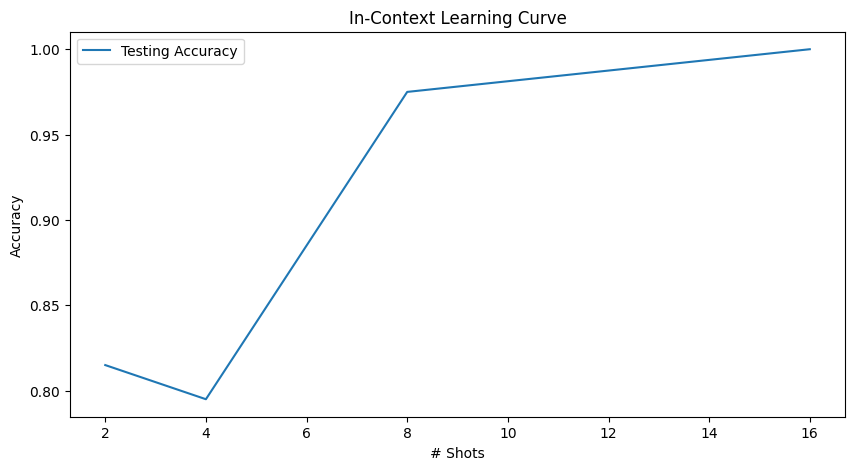

In [ ]:
import json
import matplotlib.pyplot as plt
from transformers.modelcard import parse_log_history

n_shots = shot_results.keys()
accuracy = shot_results.values()

plt.figure(figsize=(10, 5))
plt.plot(n_shots, accuracy, label='Testing Accuracy')
plt.xlabel('# Shots')
plt.ylabel('Accuracy')
plt.title('In-Context Learning Curve')
plt.legend()
plt.show()

We see that LM performance increases with more demonstration, exceeding the accuracy of our fine-tuned model without needing to update the LM's weights!

***Note:*** *This isn't a direct comparison. LM performance depends on many factors in both fine-tuning and prompting.*

# Other Options for Experimentation Setups

For real experiments, you'll need more resources than Colab provides. Here are a few pointers.

## LM Computing Platforms

Here's a quick comparison of various computing platforms you might use to fine-tune LMs or host them for prompting, in terms of:
* **Cost** of using the service
* **Availability** of hardware or hosted LMs provided by the service
* **Privacy** of data input to LMs
* **Performance** of LMs that are possible to use with the service
* **Flexibility** and control of LM interface
* **Ease** of using the service (coding, maintenance, etc.)

| Service | Fine-Tune? | Prompt? | Cost | Availability | Privacy | Performance | Flexibility | Ease |
|---|---|---|---|---|---|---|---|---|
| [Google Colab](https://research.google.com/colaboratory/) | ✔ | ✔  | ⭐ | ❌  | ⭐ | ❌ | ⭐ | 👍 |
| Proprietary Chat Interfaces (e.g., [ChatGPT](https://chat.openai.com/)) |  | ✔ | ⭐ | 👍 | ❌ | ⭐ | ❌ | ⭐ |
| [U-M GPT](https://its.umich.edu/computing/ai/gpt-in-depth) |  | ✔ | ⭐ | 👍 | ❓ | ⭐ | ❌ | ⭐ |
| [U-M Maizey](https://its.umich.edu/computing/ai/maizey-in-depth) | ✔ | ✔ | 👍 | ⭐ | ❓ | ⭐ | 👍 | ⭐ |
| [U-M Great Lakes]( https://arc.umich.edu/greatlakes/ )  (also see [UMRCP](https://arc.umich.edu/umrcp/)) | ✔ | ✔ | 👍 | 👍 | ❓ | 👍 | ⭐ | 👍 |
| Proprietary APIs (e.g., [OpenAI API](https://platform.openai.com/docs/api-reference), [Azure AI](ml.azure.com)) | ✔ | ✔ | ❌ | ⭐ | ❌ | ⭐ | 👍 | 👍 |
| Buying your own server | ✔ | ✔ | ❌ | 👍 | ⭐ | 👍 | ⭐ | ❌ |
| Cloud providers (e.g., [AWS](https://aws.amazon.com/), [Google Cloud](https://cloud.google.com/), [Azure](https://azure.microsoft.com/en-us)) | ✔ | ✔ | ❌ | ⭐ | ⭐ | 👍 | ⭐ | ❌ |



⭐ = great!

👍 = good

❌ = prohibitive

❓ = unsure/depends


***Note:*** *When applying LMs for research studies with sensitive data, check that your chosen service complies with U-M requirements by checking [here](https://safecomputing.umich.edu/dataguide/) and/or with your IRB administrator.*

## Virtual Environments
In most of the above settings, you'll have to set up a virtual environment using tools like **[conda](https://conda.io/activation)** or **[Poetry](https://python-poetry.org/)** in order to execute code. You can install `datasets`, `transformers`, and `peft` to access the same tools we used here.

Then you'll need to ensure your environment can be used in a Python notebook by following steps like those listed [here](https://medium.com/@nrk25693/how-to-add-your-conda-environment-to-your-jupyter-notebook-in-just-4-steps-abeab8b8d084).




# Acknowledgements

Some material for this tutorial was adapted from previous tutorials:
* [Hugging Face "Fine-tuning with custom datasets" tutorial](https://huggingface.co/transformers/v3.4.0/custom_datasets.html)
* [Rakesh Rajpurohit's tutorial for "Customized Evaluation Metrics with Hugging Face Trainer"](https://medium.com/@rakeshrajpurohit/customized-evaluation-metrics-with-hugging-face-trainer-3ff00d936f99)
* [Hugging Face "LoRA for Token Classification" tutorial](https://huggingface.co/docs/peft/task_guides/token-classification-lora)
* [Hugging Face pipelines documentation](https://huggingface.co/docs/transformers/main_classes/pipelines)